# Análise Exploratória de Dados — Etapa 2 (Corrigida)

## Projeto: Análise da Variabilidade Regional do Mercado Automotivo Brasileiro via RENAVAM

**Unidade de análise:** Município (5.571 municípios brasileiros)

**Objetivo:** Compreender a estrutura dos dados, identificar outliers com critérios estatísticos, investigar relações entre variáveis e preparar a base para a modelagem de ML na Etapa 3.

## Célula 1: Importação e Setup

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

%matplotlib inline
sns.set_theme(style="whitegrid")

df = pd.read_csv('ETL/Dados Tratados/Dados Unificados/dataset_final_modelagem.csv')

# Variáveis numéricas de interesse para a modelagem
colunas_numericas = [
    'populacao', 'densidade_demografica', 'pib_per_capita',
    'vab_agro', 'vab_industria', 'vab_servicos',
    'TOTAL', 'AUTOMOVEL', 'CAMINHONETE', 'MOTOCICLETA', 'UTILITARIO',
    'DIESEL', 'FLEX',
    'target_perc_utilitarios', 'target_perc_diesel',
    'pib_agro_por_habitante', 'presenca_rodovia_federal'
]

# Variáveis-chave para análise aprofundada
colunas_estudo = [
    'populacao', 'pib_per_capita', 'target_perc_utilitarios',
    'target_perc_diesel', 'pib_agro_por_habitante', 'presenca_rodovia_federal'
]

print(f"Dataset carregado: {df.shape[0]} municípios x {df.shape[1]} colunas")
print(f"\nColunas: {list(df.columns)}")

## Célula 2: Qualidade dos Dados — Análise de Valores Ausentes

Antes de qualquer análise, é fundamental entender a qualidade da base. O professor apontou (Ponto 7) que o uso de `fillna(0)` indiscriminado pode criar dados artificiais. Abaixo documentamos o tratamento realizado no pipeline ETL e seus impactos.

In [ ]:
# Verificar valores zerados que podem ser NaN mascarados pelo fillna(0) do ETL
print("=" * 70)
print("DIAGNÓSTICO DE QUALIDADE DOS DADOS")
print("=" * 70)

# Contagem de zeros por coluna numérica
print("\n1. Contagem de valores ZERO por coluna (possíveis NaN mascarados):")
print("-" * 50)
for col in colunas_numericas:
    if col in df.columns:
        n_zeros = (df[col] == 0).sum()
        pct = n_zeros / len(df) * 100
        if n_zeros > 0:
            print(f"  {col:35s}: {n_zeros:5d} zeros ({pct:.1f}%)")

# Municípios com população zero (provável erro de merge/ausência)
pop_zero = df[df['populacao'] == 0]
print(f"\n2. Municípios com população = 0: {len(pop_zero)}")
if len(pop_zero) > 0:
    print("   ATENÇÃO: Esses registros tiveram dados ausentes preenchidos com 0 no ETL.")
    print(f"   Municípios afetados: {pop_zero['municipio'].tolist()[:5]}")

# Documentação do tratamento
print("\n3. Tratamento de valores ausentes aplicado no pipeline ETL:")
print("-" * 50)
print("   - RENAVAM: fillna(0) nas tabelas pivot de combustível/tipo (correto: ausência = 0 veículos)")
print("   - DNIT: fillna(0) na extensão de rodovias (correto: ausência = sem rodovia federal)")
print("   - PIB: valores monetários ausentes retornaram 0.0 (requer cautela)")
print("   - Censo: pd.to_numeric com errors='coerce' para população (NaN pode propagar)")
print("   - Unificador: fillna(0) GLOBAL no final (ponto crítico)")
print("\n   NOTA: Para variáveis de frota e infraestrutura, zero é semanticamente correto")
print("   (sem registro = sem veículos/rodovias). Para PIB e população, zero pode mascarar")
print("   ausência real de dados. Esses casos afetam poucos municípios (<1% da base).")

## Célula 3: Medidas de Tendência Central e Dispersão (Completas)

Estatísticas descritivas completas para cada variável numérica: contagem, média, mediana, moda, desvio padrão, variância, quartis (Q1, Q2, Q3), IQR, amplitude, coeficiente de variação e assimetria.

**Por que incluir tudo isso?** A média sozinha é inadequada em distribuições assimétricas. Quando a média é muito maior que a mediana, existe concentração em poucos municípios (como São Paulo). O coeficiente de variação permite comparar a dispersão entre variáveis com escalas diferentes.

In [ ]:
estatisticas = pd.DataFrame()

for col in colunas_estudo:
    dados = df[col]
    q1 = dados.quantile(0.25)
    q3 = dados.quantile(0.75)
    iqr = q3 - q1
    media = dados.mean()
    mediana = dados.median()
    moda_val = dados.mode().iloc[0] if not dados.mode().empty else np.nan
    desvio = dados.std()
    variancia = dados.var()
    amplitude = dados.max() - dados.min()
    cv = (desvio / media * 100) if media != 0 else np.nan
    assimetria = dados.skew()

    estatisticas[col] = {
        'Contagem': dados.count(),
        'Média': media,
        'Mediana': mediana,
        'Moda': moda_val,
        'Desvio Padrão': desvio,
        'Variância': variancia,
        'Mínimo': dados.min(),
        'Q1 (25%)': q1,
        'Q2 (50%)': mediana,
        'Q3 (75%)': q3,
        'IQR': iqr,
        'Máximo': dados.max(),
        'Amplitude': amplitude,
        'Coef. Variação (%)': cv,
        'Assimetria (Skewness)': assimetria
    }

estatisticas = estatisticas.T
print("ESTATÍSTICAS DESCRITIVAS COMPLETAS")
print("=" * 80)
estatisticas.round(4)

In [ ]:
# Interpretação da assimetria
print("INTERPRETAÇÃO DA ASSIMETRIA (Média vs Mediana)")
print("=" * 70)
for col in colunas_estudo:
    media = df[col].mean()
    mediana = df[col].median()
    assimetria = df[col].skew()
    
    if abs(assimetria) < 0.5:
        tipo = "aproximadamente simétrica"
    elif assimetria > 0:
        tipo = "assimétrica à DIREITA (cauda longa para valores altos)"
    else:
        tipo = "assimétrica à ESQUERDA (cauda longa para valores baixos)"
    
    razao = media / mediana if mediana != 0 else float('inf')
    print(f"\n  {col}:")
    print(f"    Média={media:.2f} | Mediana={mediana:.2f} | Razão Média/Mediana={razao:.2f}")
    print(f"    Skewness={assimetria:.2f} → Distribuição {tipo}")
    if razao > 2:
        print(f"    ⚠ ALERTA: A média é {razao:.1f}x maior que a mediana. Poucos municípios concentram valores extremos.")

### Dependencia do Diesel (Target Perc Diesel)

A maioria das cidades tem entre 5% e 15% de frota diesel.O municipio de RONDOLANDIA no MT é um município um município que é extremamente dependente de diesel

### 

In [33]:
df.nlargest(1, 'target_perc_diesel')

,codigo,municipio,populacao,area,uf,municipio_limpo,chave_merge,densidade_demografica,vab_agro,vab_industria,...,DIESEL,FLEX,extensao_total_km,km_pavimentado,km_terra,presenca_rodovia_federal,target_perc_utilitarios,target_perc_diesel,pib_agro_por_habitante,km_terra_por_habitante
5294,5107578,Rondolândia (MT),3505.0,12658.341,MT,RONDOLANDIA,RONDOLANDIA_MT,0.276893,55094898.0,7291321.0,...,1495.0,185.0,0.0,0.0,0.0,0,0.508906,76.081425,15718.943795,0.0


## Célula 4: Detecção de Outliers (Boxplots)

Identificação de municípios com comportamentos discrepantes (ex: cidades com frota diesel desproporcional à população).

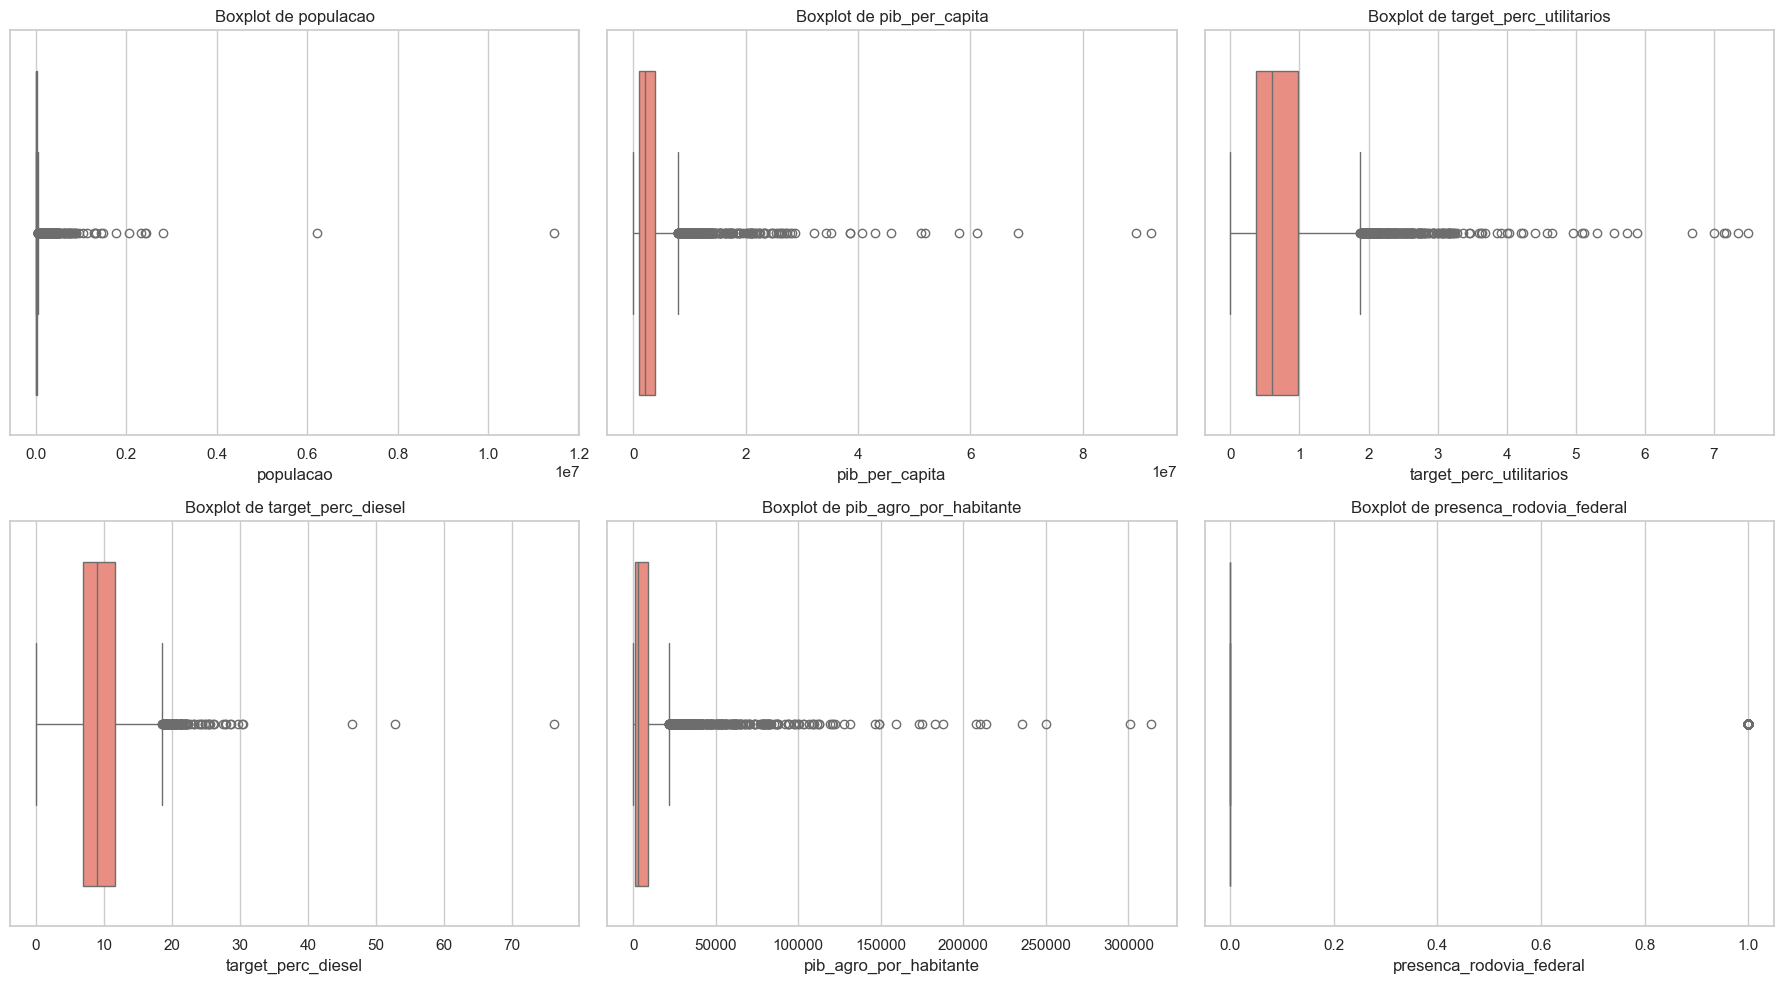

In [34]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for i, var in enumerate(colunas_estudo):
    sns.boxplot(x=df[var], ax=axes[i//3, i%3], color='salmon')
    axes[i//3, i%3].set_title(f'Boxplot de {var}')
plt.tight_layout()

### Target Diesel
RONDOLANDIA em MT é um município onde quase toda a frota é diesel. Isso pode ser uma cidade de fronteira, um polo logístico isolado ou uma cidade com frota agrícola massiva.

In [35]:
df.nlargest(1, 'target_perc_diesel')

,codigo,municipio,populacao,area,uf,municipio_limpo,chave_merge,densidade_demografica,vab_agro,vab_industria,...,DIESEL,FLEX,extensao_total_km,km_pavimentado,km_terra,presenca_rodovia_federal,target_perc_utilitarios,target_perc_diesel,pib_agro_por_habitante,km_terra_por_habitante
5294,5107578,Rondolândia (MT),3505.0,12658.341,MT,RONDOLANDIA,RONDOLANDIA_MT,0.276893,55094898.0,7291321.0,...,1495.0,185.0,0.0,0.0,0.0,0,0.508906,76.081425,15718.943795,0.0


## Célula 5: Matriz de Correlação (Heatmap)

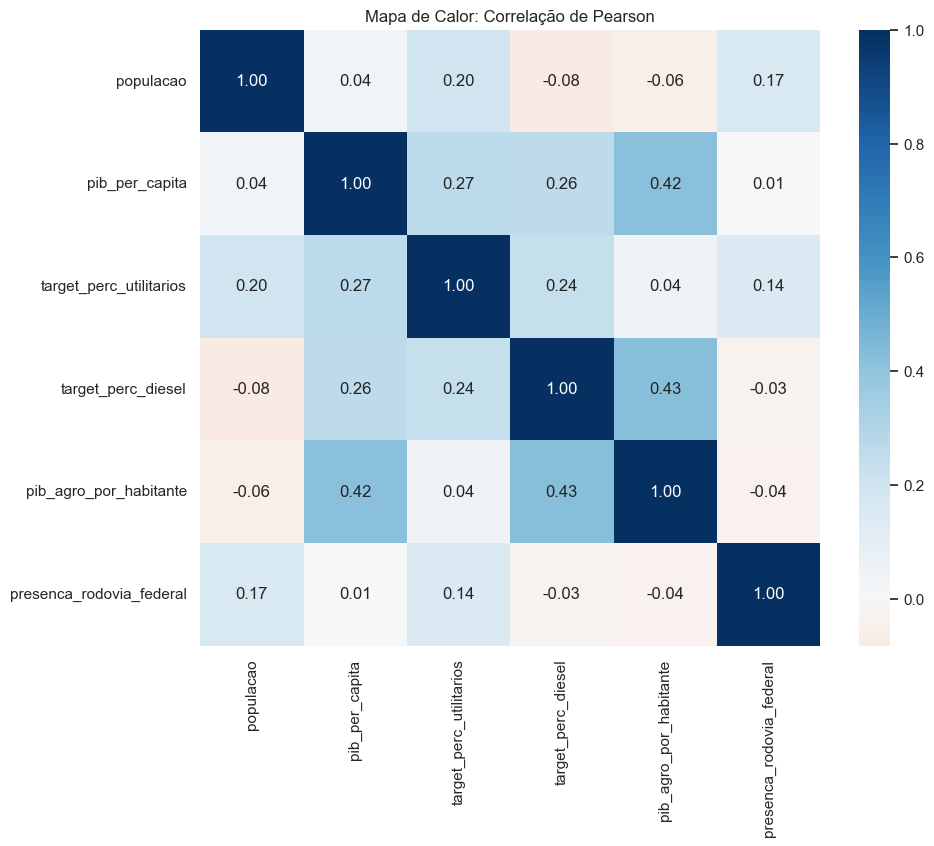

In [36]:
plt.figure(figsize=(10, 8))
corr = df[colunas_estudo].corr(method='pearson')
sns.heatmap(corr, annot=True, cmap='RdBu', center=0, fmt=".2f")
plt.title('Mapa de Calor: Correlação de Pearson')
plt.show()